In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
ruta = '../data/'
archivos = ['users.csv', 'orders.csv', 'order_items.csv', 'products.csv', 
            'distribution_centers.csv', 'events.csv', 'inventory_items.csv']


In [14]:
def ejecutar_limpieza():
    print("Fase 1: Limpieza de datos")
    for nombre in archivos:
        df = pd.read_csv(ruta + nombre)
        df.columns = df.columns.str.strip()
        
        print("\nRevisando:", nombre.upper())
        print("Dimensiones (filas, columnas):", df.shape)
        print("Tipos de datos:", df.dtypes)
        print("Valores nulos por columna:\n", df.isnull().sum())
        print("Total de duplicados:", df.duplicated().sum())
        print("Valores unicos por columna:\n", df.nunique())
        print("Resumen estadistico:\n", df.describe())
        
if __name__ == "__main__":
    ejecutar_limpieza()

Fase 1: Limpieza de datos

Revisando: USERS.CSV
Dimensiones (filas, columnas): (100000, 15)
Tipos de datos: id                  int64
first_name         object
last_name          object
email              object
age                 int64
gender             object
state              object
street_address     object
postal_code        object
city               object
country            object
latitude          float64
longitude         float64
traffic_source     object
created_at         object
dtype: object
Valores nulos por columna:
 id                  0
first_name          0
last_name           0
email               0
age                 0
gender              0
state               0
street_address      0
postal_code         0
city              958
country             0
latitude            0
longitude           0
traffic_source      0
created_at          0
dtype: int64
Total de duplicados: 0
Valores unicos por columna:
 id                100000
first_name           690
last_name      

Fase 2: Exploracion de datos (EDA)

Explorando: USERS.CSV
Primeras filas (Head):
      id   first_name last_name                           email  age gender  \
0    457      Timothy      Bush         timothybush@example.net   65      M   
1   6578    Elizabeth  Martinez   elizabethmartinez@example.com   34      F   
2  36280  Christopher   Mendoza  christophermendoza@example.net   13      M   
3  60193        Jimmy    Conner         jimmyconner@example.com   64      M   
4  64231      Natasha    Wilson       natashawilson@example.net   25      F   

  state                street_address postal_code        city country  \
0  Acre           87620 Johnson Hills   69917-400  Rio Branco  Brasil   
1  Acre             1705 Nielsen Land   69917-400  Rio Branco  Brasil   
2  Acre      125 Turner Isle Apt. 264   69917-400  Rio Branco  Brasil   
3  Acre     0966 Jose Branch Apt. 008   69917-400  Rio Branco  Brasil   
4  Acre  20798 Phillip Trail Apt. 392   69917-400  Rio Branco  Brasil   

   la

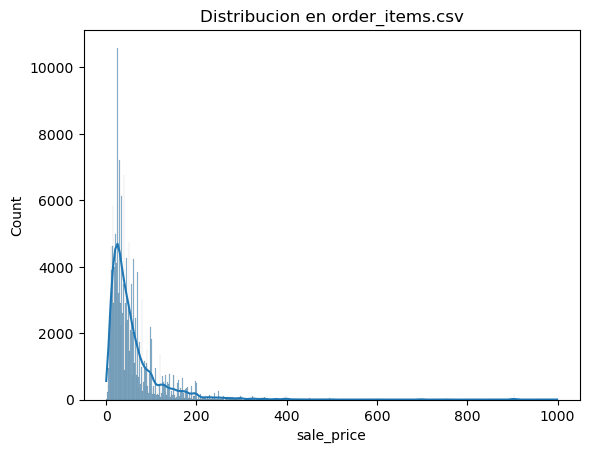


Explorando: PRODUCTS.CSV
Primeras filas (Head):
      id     cost     category  \
0  13842  2.51875  Accessories   
1  13928  2.33835  Accessories   
2  14115  4.87956  Accessories   
3  14157  4.64877  Accessories   
4  14273  6.50793  Accessories   

                                                name brand  retail_price  \
0   Low Profile Dyed Cotton Twill Cap - Navy W39S55D    MG          6.25   
1  Low Profile Dyed Cotton Twill Cap - Putty W39S55D    MG          5.95   
2       Enzyme Regular Solid Army Caps-Black W35S45D    MG         10.99   
3  Enzyme Regular Solid Army Caps-Olive W35S45D (...    MG         10.99   
4              Washed Canvas Ivy Cap - Black W11S64C    MG         15.99   

  department                               sku  distribution_center_id  
0      Women  EBD58B8A3F1D72F4206201DA62FB1204                       1  
1      Women  2EAC42424D12436BDD6A5B8A88480CC3                       1  
2      Women  EE364229B2791D1EF9355708EFF0BA34                       1

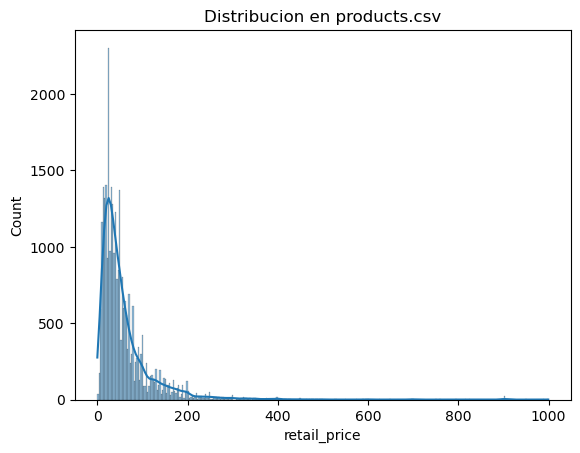


Explorando: DISTRIBUTION_CENTERS.CSV
Primeras filas (Head):
   id            name  latitude  longitude
0   1      Memphis TN   35.1174   -89.9711
1   2      Chicago IL   41.8369   -87.6847
2   3      Houston TX   29.7604   -95.3698
3   4  Los Angeles CA   34.0500  -118.2500
4   5  New Orleans LA   29.9500   -90.0667

Informacion general (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10 non-null     int64  
 1   name       10 non-null     object 
 2   latitude   10 non-null     float64
 3   longitude  10 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 452.0+ bytes
None

Matriz de correlacion:
                 id  latitude  longitude
id         1.000000 -0.233658   0.455913
latitude  -0.233658  1.000000   0.353898
longitude  0.455913  0.353898   1.000000

Explorando: EVENTS.CSV
Primeras filas (Head):
    

In [15]:
def ejecutar_eda():
    print("Fase 2: Exploracion de datos (EDA)")
    for nombre in archivos:
        df = pd.read_csv(ruta + nombre)
        
        print("\nExplorando:", nombre.upper())
        print("Primeras filas (Head):")
        print(df.head())
        
        print("\nInformacion general (Info):")
        print(df.info())
        
        print("\nMatriz de correlacion:")
        # numeric_only=True evita errores con las columnas de texto
        print(df.corr(numeric_only=True))

        # Grafica de distribucion (solo si hay precios)
        col = "sale_price" if "sale_price" in df.columns else "retail_price" if "retail_price" in df.columns else None
        if col:
            sns.histplot(df[col], kde=True)
            plt.title("Distribucion en " + nombre)
            plt.show()

if __name__ == "__main__":
    ejecutar_eda()

In [20]:
ruta = "../data/"
ruta_salida = "../data/processed/"

def ejecutar_limpieza_final():
    print("Iniciando el proceso de limpieza...")

    # 1. USERS.CSV
    print("Procesando users.csv")
    users = pd.read_csv(ruta + "users.csv")
    users.columns = users.columns.str.strip() # Esto elimina los espacios en blanco que sobran al principio y al final de cada nombre de columna
    users["created_at"] = pd.to_datetime(users["created_at"], format="ISO8601").dt.tz_localize(None)
    users["city"] = users["city"].fillna("Unknown") # Las ciudades en null las ponemos como desconocidas (Unknown)
    users.to_csv(ruta_salida + "users_clean.csv", index=False)

    # 2. ORDERS.CSV
    print("Procesando orders.csv")
    orders = pd.read_csv(ruta + "orders.csv")
    orders.columns = orders.columns.str.strip()
    columnas_fecha_orders = ["created_at", "returned_at", "shipped_at", "delivered_at"]
    for col in columnas_fecha_orders:
        orders[col] = pd.to_datetime(orders[col], format="ISO8601").dt.tz_localize(None)
    orders.to_csv(ruta_salida + "orders_clean.csv", index=False)

    # 3. ORDER_ITEMS.CSV
    print("Procesando order_items.csv")
    items = pd.read_csv(ruta + "order_items.csv")
    items.columns = items.columns.str.strip()
    items["shipped_at"] = pd.to_datetime(items["shipped_at"], format="ISO8601").dt.tz_localize(None)
    items["delivered_at"] = pd.to_datetime(items["delivered_at"], format="ISO8601").dt.tz_localize(None)
    items["returned_at"] = pd.to_datetime(items["returned_at"], format="ISO8601").dt.tz_localize(None)
    items["created_at"] = pd.to_datetime(items["created_at"], format="ISO8601").dt.tz_localize(None)
    items.to_csv(ruta_salida + "order_items_clean.csv", index=False)

    # 4. PRODUCTS.CSV
    print("Procesando products.csv")
    products = pd.read_csv(ruta + "products.csv")
    products.columns = products.columns.str.strip() # Esto elimina los espacios en blanco que sobran
    products["name"] = products["name"].fillna("Unknown Product")
    marcas_manuales = {
        16898: "Quicksilver", 1629: "Carhartt", 27640: "O'Neill",
        25135: "Volcom", 24287: "adidas", 25187: "SockGuy",
        27543: "Harbor Bay", 23769: "Stormtech", 21207: "Ariat",
        21484: "True Nation", 16559: "Gildan", 16309: "Hurley",
        9482: "Keen", 10598: "JMS", 11389: "Shadowline"
    }
    products["brand"] = products["id"].map(marcas_manuales).fillna(products["brand"])
    products["brand"] = products["brand"].fillna("Unknown Brand")
    products.to_csv(ruta_salida + "products_clean.csv", index=False)

    # 5. DISTRIBUTION_CENTERS.CSV
    print("Procesando distribution_centers.csv")
    centers = pd.read_csv(ruta + "distribution_centers.csv")
    centers.columns = centers.columns.str.strip()
    centers.to_csv(ruta_salida + "distribution_centers_clean.csv", index=False)

    # 6. EVENTS.CSV
    print("Procesando events.csv")
    events = pd.read_csv(ruta + "events.csv")
    events.columns = events.columns.str.strip()
    events["created_at"] = pd.to_datetime(events["created_at"], format="ISO8601").dt.tz_localize(None)
    events["city"] = events["city"].fillna("Unknown")
    # Clasificación de usuarios: registrados vs no registrados
    events["user_type"] = events["user_id"].isnull().map({True: "anonymous", False: "registered"})
    events.to_csv(ruta_salida + "events_clean.csv", index=False)

    # 7. INVENTORY_ITEMS.CSV
    print("Procesando inventory_items.csv")
    inventory = pd.read_csv(ruta + "inventory_items.csv")
    inventory.columns = inventory.columns.str.strip()
    inventory["product_name"] = inventory["product_name"].fillna("Unknown Product")
    inventory["product_brand"] = inventory["product_brand"].fillna("Unknown Brand")
    inventory["created_at"] = pd.to_datetime(inventory["created_at"], format="ISO8601").dt.tz_localize(None)
    inventory["sold_at"] = pd.to_datetime(inventory["sold_at"], format="ISO8601").dt.tz_localize(None)
    inventory.to_csv(ruta_salida + "inventory_clean.csv", index=False)

    print("Limpieza finalizada. Archivos guardados en data/processed/")

if __name__ == "__main__":
    ejecutar_limpieza_final()

Iniciando el proceso de limpieza...
Procesando users.csv
Procesando orders.csv
Procesando order_items.csv
Procesando products.csv
Procesando distribution_centers.csv
Procesando events.csv
Procesando inventory_items.csv
Limpieza finalizada. Archivos guardados en data/processed/
